In [3]:
# Cell 1 — Setup
import sys
for mod in list(sys.modules.keys()):
    if mod in ('config','data_loader','preprocessor',
               'trainer','evaluator','explainer'):
        del sys.modules[mod]
sys.path.insert(0, '../src')

import warnings, joblib, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

from data_loader import (load_raw_data, clean_dependents,
                          handle_credit_history, encode_target,
                          engineer_features, get_X_y, get_train_val_split)
from trainer     import train_all_models
from explainer   import (get_shap_explainer, plot_global_importance,
                          plot_beeswarm, explain_single_applicant)

df, _ = load_raw_data()
df    = clean_dependents(df)
df    = handle_credit_history(df)
df    = encode_target(df)
df    = engineer_features(df)

X, y  = get_X_y(df)
X_train, X_val, y_train, y_val = get_train_val_split(X, y)

# Train with engineered features (best config)
from preprocessor import build_preprocessor
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pre      = build_preprocessor(use_engineered=True)
rf       = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
pipeline = Pipeline([("preprocessor", pre), ("classifier", rf)])
pipeline.fit(X_train, y_train)

print("Pipeline trained and ready for SHAP analysis.")

Pipeline trained and ready for SHAP analysis.


In [4]:
# Cell 2 — Build SHAP explainer (takes ~30 seconds)
explainer, shap_values, feature_names, X_train_proc = get_shap_explainer(
    pipeline, X_train
)
print(f"SHAP explainer ready.")
print(f"Feature count : {len(feature_names)}")
print(f"SHAP array    : {shap_values.values.shape}")

 97%|=================== | 956/982 [00:49<00:01]       

SHAP explainer ready.
Feature count : 21
SHAP array    : (491, 21, 2)


Saved: ../data/processed/shap_global_importance.png


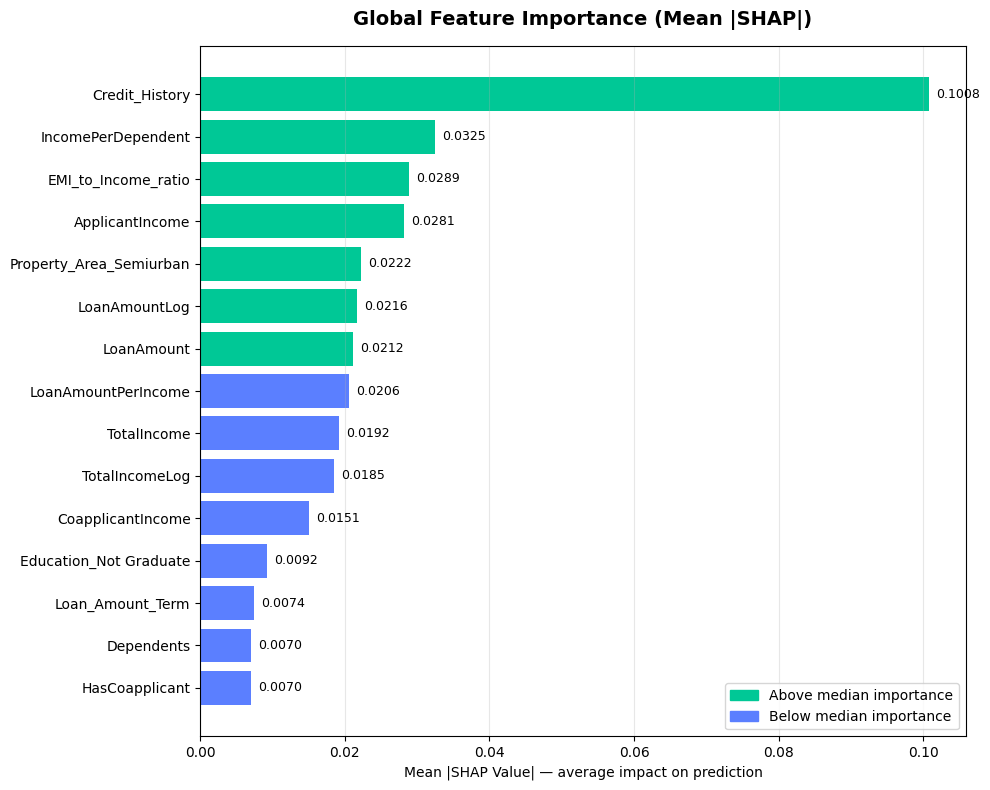


Top 5 most important features:
  Credit_History                 mean|SHAP| = 0.1008
  IncomePerDependent             mean|SHAP| = 0.0325
  EMI_to_Income_ratio            mean|SHAP| = 0.0289
  ApplicantIncome                mean|SHAP| = 0.0281
  Property_Area_Semiurban        mean|SHAP| = 0.0222


,feature,importance
20,HasCoapplicant,0.006978
11,Dependents,0.007027
3,Loan_Amount_Term,0.007408
6,Education_Not Graduate,0.009174
1,CoapplicantIncome,0.015075
17,TotalIncomeLog,0.018516
12,TotalIncome,0.019212
13,LoanAmountPerIncome,0.020625
2,LoanAmount,0.021151
16,LoanAmountLog,0.021615


In [5]:
# Cell 3 — Global importance bar chart
plot_global_importance(
    shap_values, feature_names,
    top_n=15,
    save_path='../data/processed/shap_global_importance.png'
)

Saved: ../data/processed/shap_beeswarm.png


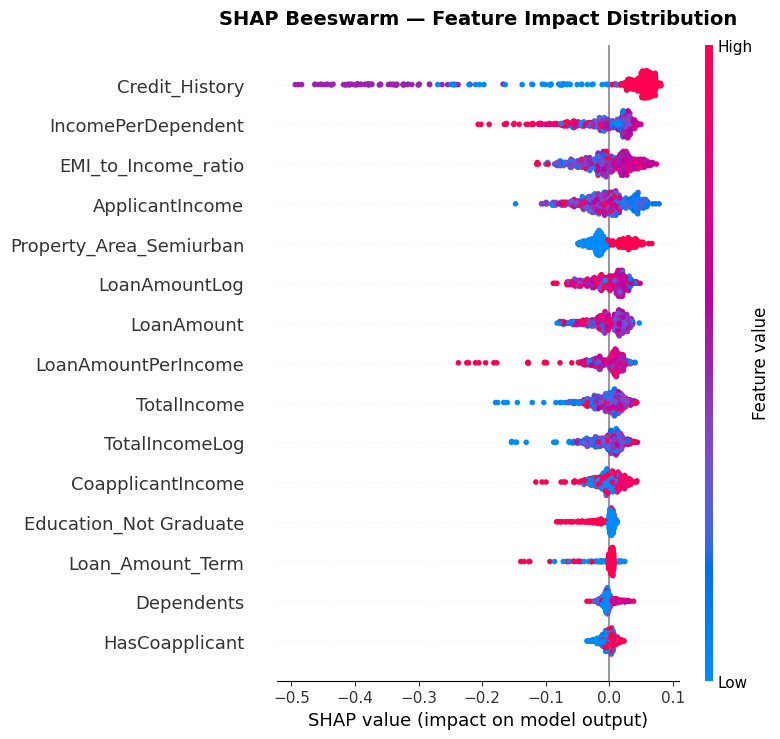

In [6]:
# Cell 4 — Beeswarm (most impressive chart for README)
plot_beeswarm(
    shap_values, feature_names,
    save_path='../data/processed/shap_beeswarm.png'
)

True Positives  (correct approvals)  : 44
True Negatives  (correct rejections) : 34
False Positives (wrong approvals)    : 4
False Negatives (wrong rejections)   : 41
Saved: ../data/processed/shap_tr.png


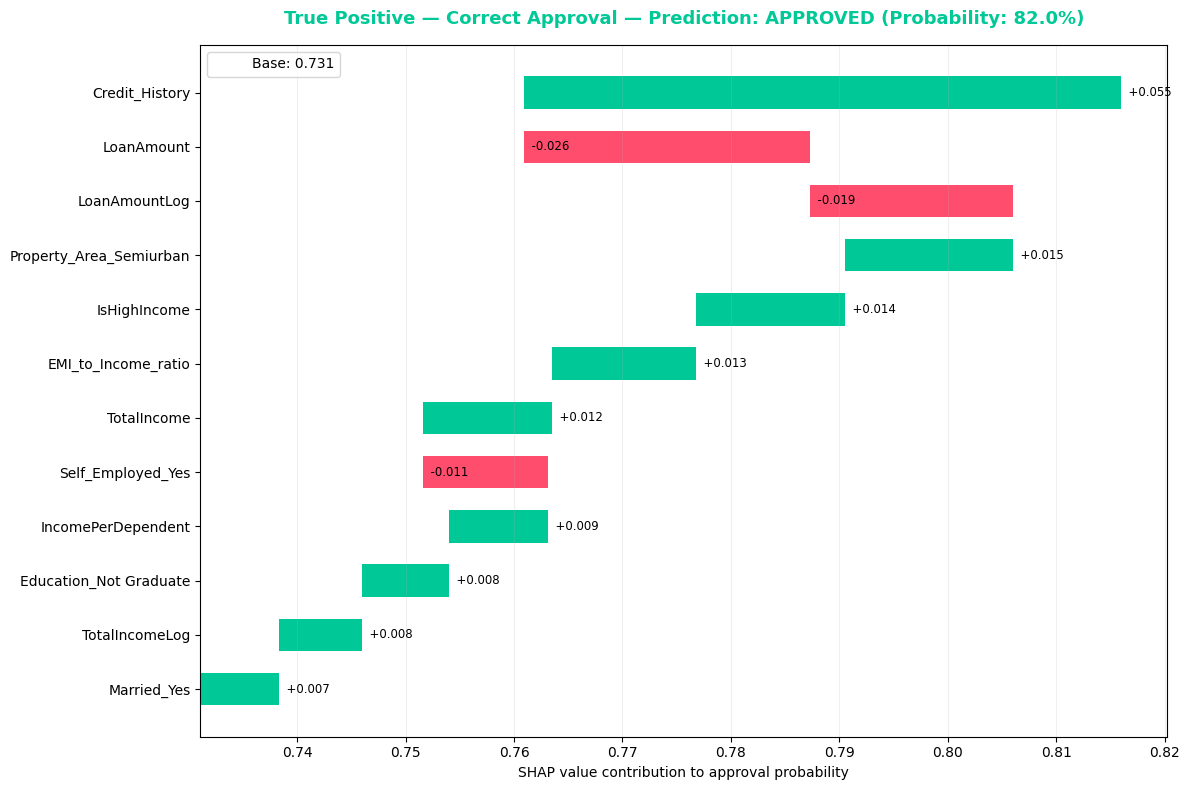


  True Positive — Correct Approval Explanation Report
  Decision     : APPROVED
  Probability  : 82.0%
  Base rate    : 73.1%

  Top factors pushing toward APPROVAL:
    ✓ Credit_History               +0.0551
    ✓ Property_Area_Semiurban      +0.0155
    ✓ IsHighIncome                 +0.0138

  Top factors pushing toward REJECTION:
    ✗ LoanAmount                   -0.0264
    ✗ LoanAmountLog                -0.0187
    ✗ Self_Employed_Yes            -0.0115
Saved: ../data/processed/shap_tr.png


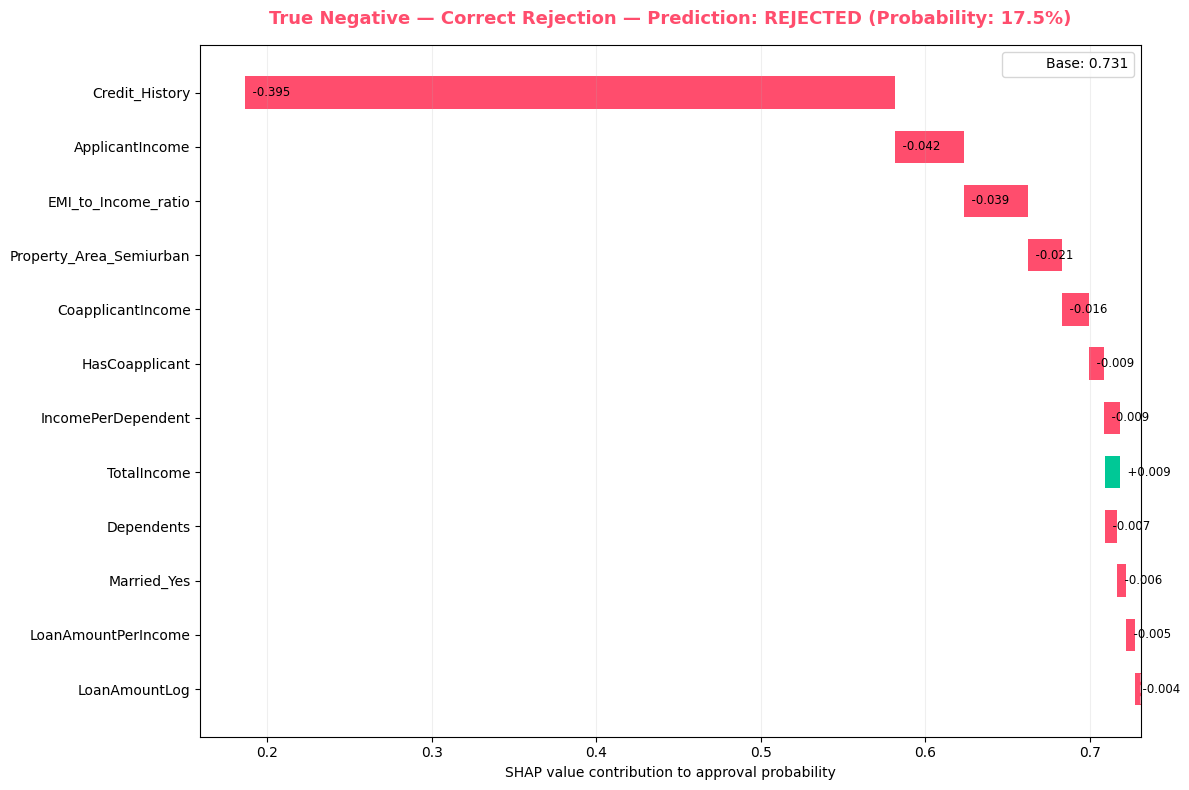


  True Negative — Correct Rejection Explanation Report
  Decision     : REJECTED
  Probability  : 17.5%
  Base rate    : 73.1%

  Top factors pushing toward APPROVAL:
    ✓ TotalIncome                  +0.0088

  Top factors pushing toward REJECTION:
    ✗ Credit_History               -0.3949
    ✗ ApplicantIncome              -0.0423
    ✗ EMI_to_Income_ratio          -0.0386
Saved: ../data/processed/shap_fa.png


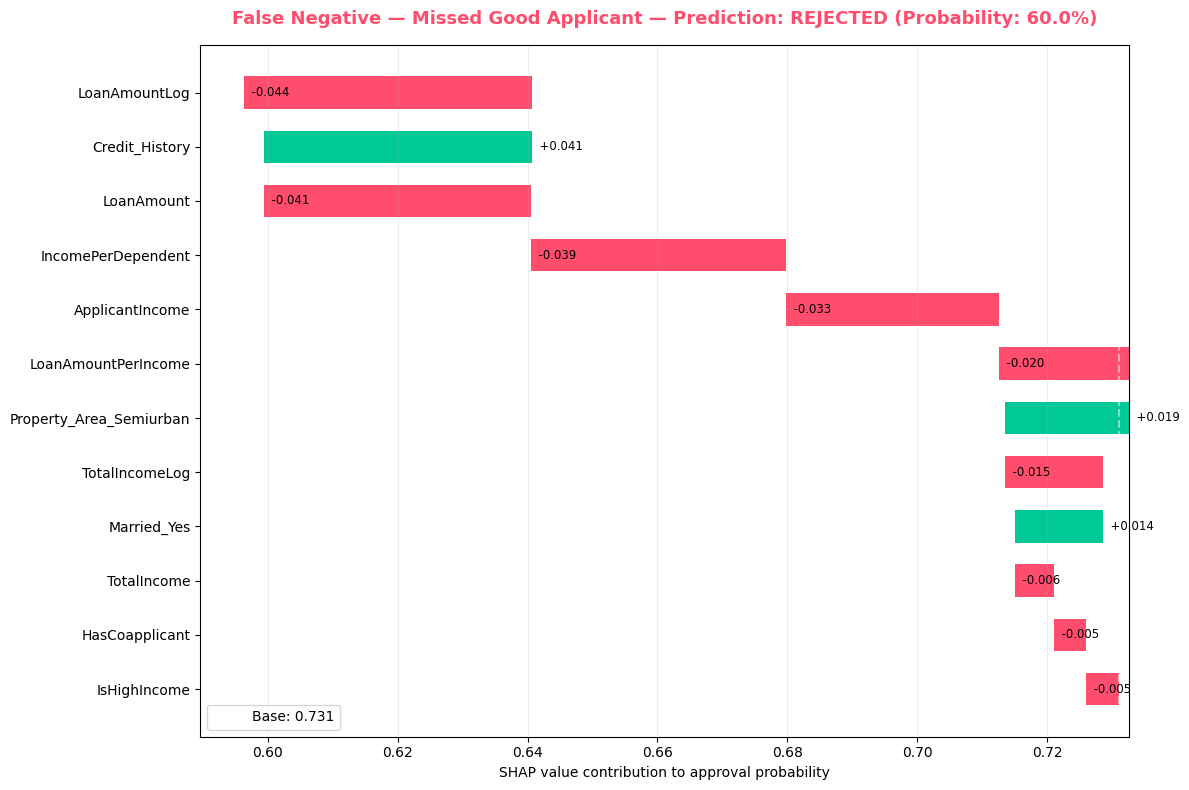


  False Negative — Missed Good Applicant Explanation Report
  Decision     : REJECTED
  Probability  : 60.0%
  Base rate    : 73.1%

  Top factors pushing toward APPROVAL:
    ✓ Credit_History               +0.0412
    ✓ Property_Area_Semiurban      +0.0192
    ✓ Married_Yes                  +0.0136

  Top factors pushing toward REJECTION:
    ✗ LoanAmountLog                -0.0442
    ✗ LoanAmount                   -0.0412
    ✗ IncomePerDependent           -0.0391


In [10]:
# Cell 5 — corrected: find a TRULY approved-and-predicted-approved applicant

# Get predictions on validation set
y_pred_val = pipeline.predict(X_val)
y_prob_val = pipeline.predict_proba(X_val)[:, 1]

# True positive: actually approved AND model predicted approved (prob >= 0.77)
tp_mask = (y_val == 1) & (y_prob_val >= 0.77)
tn_mask = (y_val == 0) & (y_prob_val < 0.77)
fp_mask = (y_val == 0) & (y_prob_val >= 0.77)   # false positive
fn_mask = (y_val == 1) & (y_prob_val < 0.77)    # false negative — your current case

print(f"True Positives  (correct approvals)  : {tp_mask.sum()}")
print(f"True Negatives  (correct rejections) : {tn_mask.sum()}")
print(f"False Positives (wrong approvals)    : {fp_mask.sum()}")
print(f"False Negatives (wrong rejections)   : {fn_mask.sum()}")

# Explain one of each — shows your model's reasoning in all four scenarios
tp_idx = y_val[tp_mask].index[0]
tn_idx = y_val[tn_mask].index[0]
fn_idx = y_val[fn_mask].index[0]   # ← your current "approved applicant"

for idx, label in [(tp_idx, "True Positive — Correct Approval"),
                   (tn_idx, "True Negative — Correct Rejection"),
                   (fn_idx, "False Negative — Missed Good Applicant")]:
    explain_single_applicant(
        pipeline, X_val.loc[[idx]], explainer, feature_names,
        applicant_label=label,
        save_path=f'../data/processed/shap_{label[:2].lower().replace(" ","_")}.png'
    )

Saved: ../data/processed/shap_rejected_applicant.png


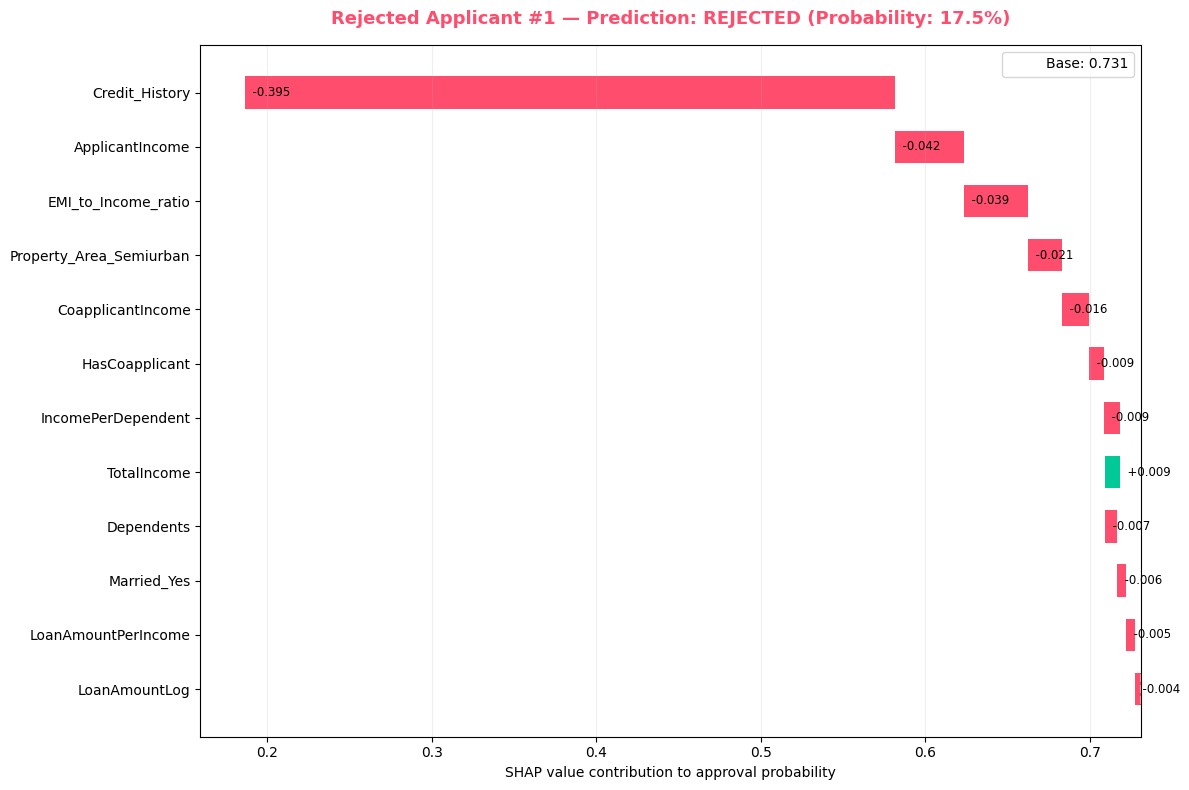


  Rejected Applicant #1 Explanation Report
  Decision     : REJECTED
  Probability  : 17.5%
  Base rate    : 73.1%

  Top factors pushing toward APPROVAL:
    ✓ TotalIncome                  +0.0088

  Top factors pushing toward REJECTION:
    ✗ Credit_History               -0.3949
    ✗ ApplicantIncome              -0.0423
    ✗ EMI_to_Income_ratio          -0.0386


,feature,shap_value,feature_value
16,LoanAmountLog,-0.003875,0.099363
13,LoanAmountPerIncome,-0.005031,-0.426056
5,Married_Yes,-0.005604,0.000000
11,Dependents,-0.007357,0.000000
12,TotalIncome,0.008776,0.123028
14,IncomePerDependent,-0.009309,0.686086
20,HasCoapplicant,-0.009347,0.000000
1,CoapplicantIncome,-0.016232,-1.087807
8,Property_Area_Semiurban,-0.020831,0.000000
15,EMI_to_Income_ratio,-0.038570,-0.317176


In [8]:
# Cell 6 — Explain a rejected applicant
rejected_idx = y_val[y_val == 0].index[0]
applicant    = X_val.loc[[rejected_idx]]

explain_single_applicant(
    pipeline, applicant, explainer, feature_names,
    applicant_label="Rejected Applicant #1",
    save_path='../data/processed/shap_rejected_applicant.png'
)

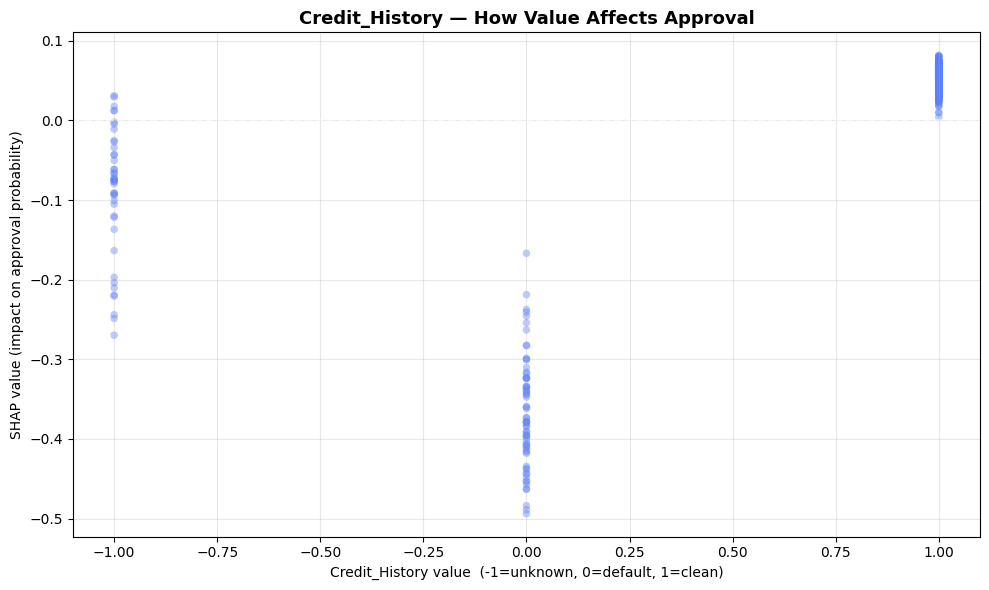

In [9]:
# Cell 7 — SHAP dependence plot for Credit_History
# Shows HOW Credit_History value affects SHAP contribution
import shap, matplotlib.pyplot as plt

if hasattr(shap_values, 'values'):
    vals = shap_values.values
    if vals.ndim == 3:
        vals = vals[:, :, 1]
    data = shap_values.data
else:
    vals = shap_values
    data = X_train_proc

ch_idx = next((i for i, n in enumerate(feature_names)
               if 'Credit_History' in n), None)

if ch_idx is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(data[:, ch_idx], vals[:, ch_idx],
               alpha=0.4, s=30, color='#5b7fff', edgecolors='none')
    ax.axhline(y=0, color='white', linestyle='--', alpha=0.5)
    ax.set_xlabel('Credit_History value  (-1=unknown, 0=default, 1=clean)')
    ax.set_ylabel('SHAP value (impact on approval probability)')
    ax.set_title('Credit_History — How Value Affects Approval',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../data/processed/shap_credit_dependence.png',
                dpi=150, bbox_inches='tight')
    plt.show()